# Name:Ankit Vaghela

# USN : 1AUA23BCS009

# Branch:CSE(B-2)

#  Lab 5: Supervised Learning-Regression using ML + ANN



##  Exercise 1: Dataset Understanding & Preprocessing
### 1. Load the dataset and display .head(), .info(), and .describe().

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


### 2.	Identify categorical and numerical features

In [5]:
cat_cols = df.select_dtypes(include='object').columns
num_cols = df.select_dtypes(exclude='object').columns
print("Categorical:", cat_cols)
print("Numerical:", num_cols)

Categorical: Index(['sex', 'smoker', 'region'], dtype='object')
Numerical: Index(['age', 'bmi', 'children', 'charges'], dtype='object')


### 3.	Handle missing values if any.

In [6]:
df.isnull().sum().sum()

np.int64(0)

### 4.	Encode categorical features using:
### • Label Encoding
### • One-Hot Encoding


In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])
df['smoker'] = le.fit_transform(df['smoker'])

In [8]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520


In [9]:
df = pd.get_dummies(df, columns=['region'], drop_first=True)

In [10]:
df.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,True
1,18,1,33.770,1,0,1725.55230,False,True,False
2,28,1,33.000,3,0,4449.46200,False,True,False
3,33,1,22.705,0,0,21984.47061,True,False,False
4,32,1,28.880,0,0,3866.85520,True,False,False


### 5.	Normalize/standardize numerical features.

In [11]:
from sklearn.preprocessing import StandardScaler

X = df.drop("charges", axis=1)
y = df["charges"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### 6.	Split the dataset into training and testing sets (80:20).

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

##  Exercise 2: Machine Learning Regression Models
### Apply the following regression models to predict charges:
### • Simple Linear Regression (using bmi only)
### • Multiple Linear Regression (all features)
### • Polynomial Regression (degree 2 and 3)
### • Ridge Regression (with tuning alpha)
### • Lasso Regression (with tuning alpha)
### • Decision Tree Regressor
### For each model:
### • Train the model
### • Predict on test data
### • Evaluate and record:
### o MAE
### o MSE
### o RMSE
### o R² Score
### • Create scatter plot of Actual vs Predicted values


In [13]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

In [14]:
def evaluate(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n🔹 {model_name}")
    print("MAE:", round(mae, 2))
    print("MSE:", round(mse, 2))
    print("RMSE:", round(rmse, 2))
    print("R2:", round(r2, 4))
    
    plt.scatter(y_true, y_pred)
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(model_name)
    plt.show()
    
   


🔹 Simple Linear Regression (BMI)
MAE: 9784.65
MSE: 149085057.04
RMSE: 12210.04
R2: 0.0397


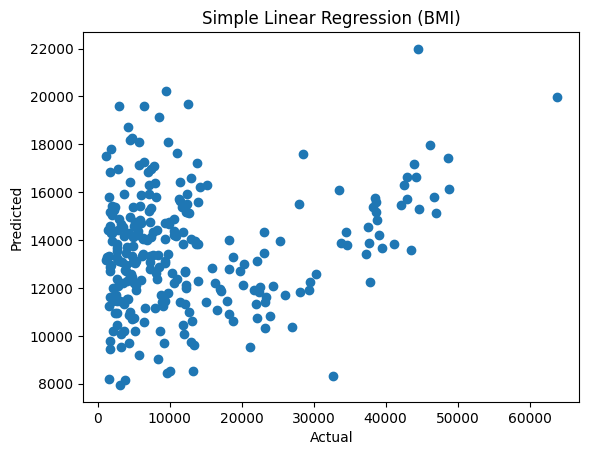

In [15]:
from sklearn.model_selection import train_test_split

X_bmi = df[['bmi']]
y_bmi = df['charges']

X_train_bmi, X_test_bmi, y_train_bmi, y_test_bmi = train_test_split(
    X_bmi, y_bmi, test_size=0.2, random_state=42)

slr = LinearRegression()
slr.fit(X_train_bmi, y_train_bmi)

pred_slr = slr.predict(X_test_bmi)
evaluate(y_test_bmi, pred_slr, "Simple Linear Regression (BMI)")


🔹 Multiple Linear Regression
MAE: 4181.19
MSE: 33596915.85
RMSE: 5796.28
R2: 0.7836


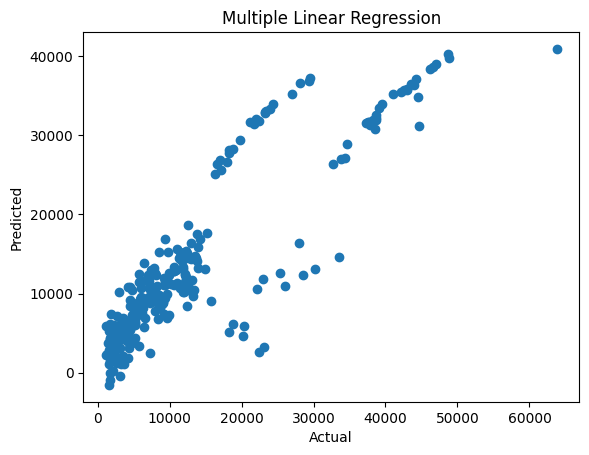

In [16]:
mlr = LinearRegression()
mlr.fit(X_train, y_train)

pred_mlr = mlr.predict(X_test)
evaluate(y_test, pred_mlr, "Multiple Linear Regression")


🔹 Polynomial Regression Degree 2
MAE: 2729.5
MSE: 20712805.99
RMSE: 4551.13
R2: 0.8666


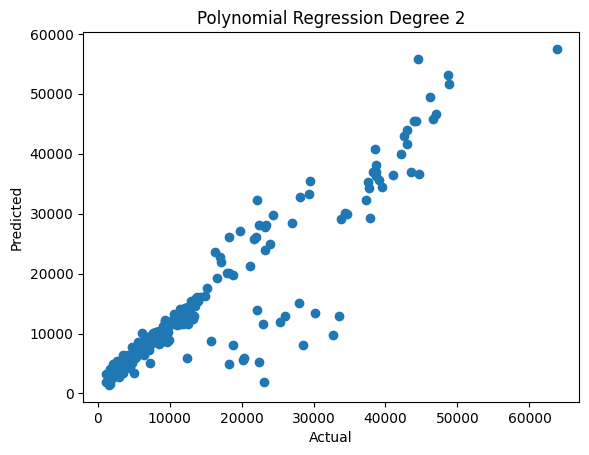

In [17]:
poly2 = PolynomialFeatures(degree=2)
X_poly2 = poly2.fit_transform(X_scaled)

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_poly2, y, test_size=0.2, random_state=42)

model2 = LinearRegression()
model2.fit(X_train2, y_train2)

pred2 = model2.predict(X_test2)
evaluate(y_test2, pred2, "Polynomial Regression Degree 2")


🔹 Polynomial Regression Degree 3
MAE: 2937.92
MSE: 23498218.0
RMSE: 4847.5
R2: 0.8486


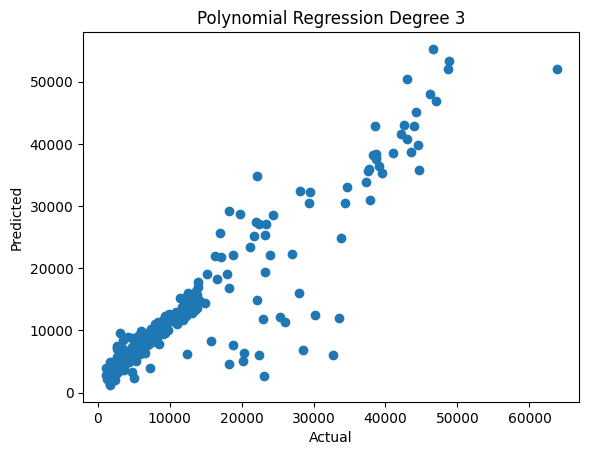

In [18]:
poly3 = PolynomialFeatures(degree=3)
X_poly3 = poly3.fit_transform(X_scaled)

X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X_poly3, y, test_size=0.2, random_state=42)

model3 = LinearRegression()
model3.fit(X_train3, y_train3)

pred3 = model3.predict(X_test3)
evaluate(y_test3, pred3, "Polynomial Regression Degree 3")


🔹 Ridge Regression
MAE: 4182.78
MSE: 33604956.54
RMSE: 5796.98
R2: 0.7835


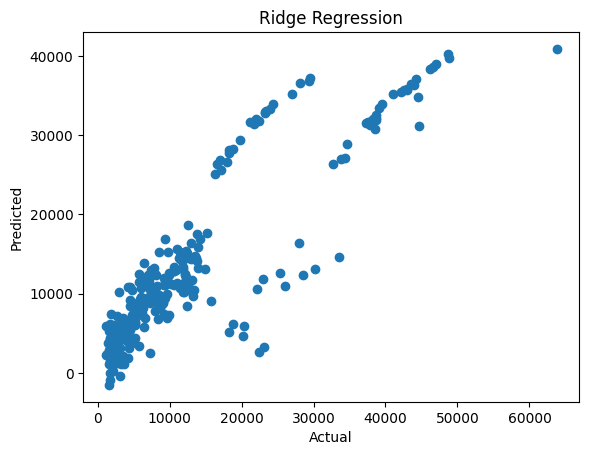

In [19]:
ridge = Ridge(alpha=1)
ridge.fit(X_train, y_train)

pred_ridge = ridge.predict(X_test)
evaluate(y_test, pred_ridge, "Ridge Regression")


🔹 Lasso Regression
MAE: 4181.23
MSE: 33597338.15
RMSE: 5796.32
R2: 0.7836


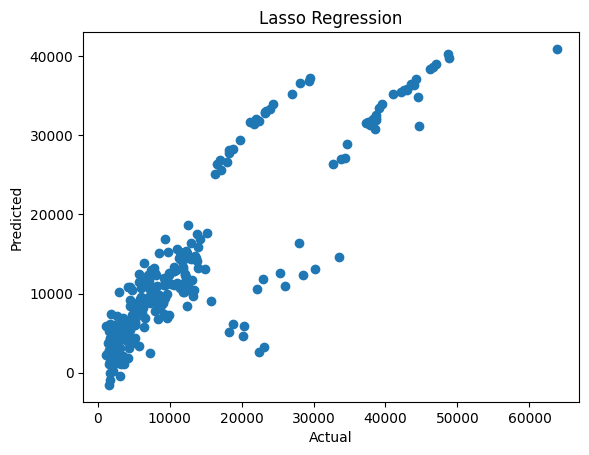

In [20]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

pred_lasso = lasso.predict(X_test)
evaluate(y_test, pred_lasso, "Lasso Regression")


🔹 Decision Tree Regressor
MAE: 3133.92
MSE: 41378354.18
RMSE: 6432.6
R2: 0.7335


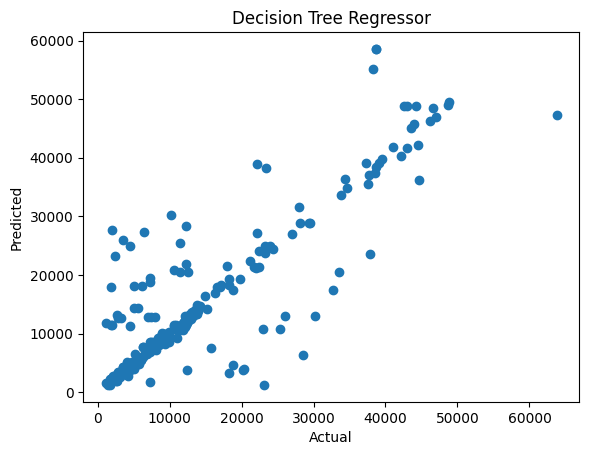

In [21]:
dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)
evaluate(y_test, pred_dt, "Decision Tree Regressor")

##  Exercise 3: Artificial Neural Network (ANN)
### Step 1: ANN Model Design
### Design a Feed-Forward Neural Network for regression with:
### • Input layer: number of neurons = number of features
### • Hidden layer(s): 1 or 2 hidden layers
### • Activation function:
### o Hidden layer: ReLU
### o Output layer: Linear activation
### • Loss function: Mean Squared Error (MSE)
### • Optimizer: Adam (default parameters)


In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

ann = Sequential()
ann.add(Dense(16, activation='relu', input_shape=(X_train.shape[1],)))
ann.add(Dense(8, activation='relu'))
ann.add(Dense(1, activation='linear'))

ann.compile(optimizer='adam', loss='mse')
ann.summary()

c:\Users\ankitr.vaghela\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
history = ann.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32
)

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 325443040.0000 - val_loss: 310334464.0000
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 325423360.0000 - val_loss: 310314752.0000
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 325398720.0000 - val_loss: 310288640.0000
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 325364960.0000 - val_loss: 310253088.0000
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 325319072.0000 - val_loss: 310204064.0000
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 325257056.0000 - val_loss: 310137376.0000
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 325172896.0000 - val_loss: 310049760.0000
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 325065120.0000 - val_loss: 309938720.0000
Epoch 9/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 324926848.0000 - val_loss: 309801536.0000
Epoch 10/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 324758624.0000 - val_loss: 309

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

🔹 ANN Regression
MAE: 6128.59
MSE: 83050468.2
RMSE: 9113.2
R2: 0.465


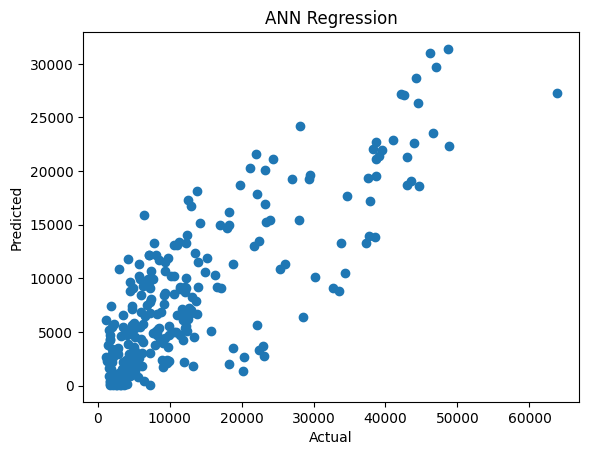

In [24]:
pred_ann = ann.predict(X_test)
evaluate(y_test, pred_ann, "ANN Regression")

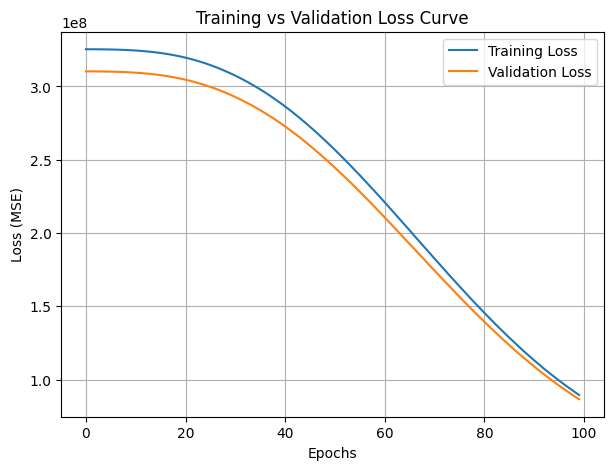

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

# Training loss
plt.plot(history.history['loss'], label='Training Loss')

# Validation loss
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.title("Training vs Validation Loss Curve")

plt.legend()
plt.grid(True)
plt.show()

##  Exercise 4: Model Comparison.
### Step 1: Create Evaluation Tables
### Table A: Training Data


In [26]:
def get_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return [mae, mse, rmse, r2]

In [27]:
train_results = {}
test_results = {}

In [28]:
train_results["SLR"] = get_metrics(y_train_bmi, slr.predict(X_train_bmi))
test_results["SLR"] = get_metrics(y_test_bmi, slr.predict(X_test_bmi))

In [29]:
train_results["MLR"] = get_metrics(y_train, mlr.predict(X_train))
test_results["MLR"] = get_metrics(y_test, mlr.predict(X_test))

In [30]:
train_results["Poly2"] = get_metrics(y_train2, model2.predict(X_train2))
test_results["Poly2"] = get_metrics(y_test2, model2.predict(X_test2))

In [31]:
train_results["Poly3"] = get_metrics(y_train3, model3.predict(X_train3))
test_results["Poly3"] = get_metrics(y_test3, model3.predict(X_test3))

In [32]:
train_results["Ridge"] = get_metrics(y_train, ridge.predict(X_train))
test_results["Ridge"] = get_metrics(y_test, ridge.predict(X_test))

In [33]:
train_results["Lasso"] = get_metrics(y_train, lasso.predict(X_train))
test_results["Lasso"] = get_metrics(y_test, lasso.predict(X_test))

In [34]:
train_results["Decision Tree"] = get_metrics(y_train, dt.predict(X_train))
test_results["Decision Tree"] = get_metrics(y_test, dt.predict(X_test))

In [35]:
train_results["ANN"] = get_metrics(y_train, ann.predict(X_train))
test_results["ANN"] = get_metrics(y_test, ann.predict(X_test))

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [36]:
model_names = {
    "SLR": "Simple Linear Regression",
    "MLR": "Multiple Linear Regression",
    "Poly2": "Polynomial Regression (Degree 2)",
    "Poly3": "Polynomial Regression (Degree 3)",
    "Ridge": "Ridge Regression",
    "Lasso": "Lasso Regression",
    "Decision Tree": "Decision Tree Regressor",
    "ANN": "ANN Regressor"
}

In [37]:
train_table = pd.DataFrame(train_results).T
train_table.columns = ["MAE", "MSE", "RMSE", "R2"]

# Add Model column with full names
train_table["Model"] = train_table.index.map(model_names)

# Reorder columns
train_table = train_table[["Model", "MAE", "MSE", "RMSE", "R2"]]

# Reset index
train_table.reset_index(drop=True, inplace=True)

print(" Training Table")
train_table

 Training Table


,Model,MAE,MSE,RMSE,R2
0,Simple Linear Regression,9067.951789,1.387142e+08,11777.698282,0.038934
1,Multiple Linear Regression,4208.234572,3.727768e+07,6105.545160,0.741726
2,Polynomial Regression (Degree 2),2892.149840,2.283108e+07,4778.187803,0.841817
3,Polynomial Regression (Degree 3),2792.779239,2.093530e+07,4575.510839,0.854952
4,Ridge Regression,4209.375392,3.727778e+07,6105.553214,0.741725
5,Lasso Regression,4208.224792,3.727768e+07,6105.545173,0.741726
6,Decision Tree Regressor,29.572515,2.442396e+05,494.205984,0.998308
7,ANN Regressor,6094.189811,8.790324e+07,9375.672922,0.390972


### Table B: Testing Data

In [38]:
test_table = pd.DataFrame(test_results).T
test_table.columns = ["MAE", "MSE", "RMSE", "R2"]

# Full model names
test_table["Model"] = test_table.index.map(model_names)

# Reorder
test_table = test_table[["Model", "MAE", "MSE", "RMSE", "R2"]]

test_table.reset_index(drop=True, inplace=True)

print(" Testing Table")
test_table

 Testing Table


,Model,MAE,MSE,RMSE,R2
0,Simple Linear Regression,9784.652596,1.490851e+08,12210.039191,0.039702
1,Multiple Linear Regression,4181.194474,3.359692e+07,5796.284659,0.783593
2,Polynomial Regression (Degree 2),2729.500134,2.071281e+07,4551.132385,0.866583
3,Polynomial Regression (Degree 3),2937.918593,2.349822e+07,4847.496055,0.848641
4,Ridge Regression,4182.780228,3.360496e+07,5796.978225,0.783541
5,Lasso Regression,4181.225849,3.359734e+07,5796.321088,0.783590
6,Decision Tree Regressor,3133.917848,4.137835e+07,6432.600887,0.733471
7,ANN Regressor,6128.593351,8.305047e+07,9113.202961,0.465049


## Exercise:5
### 1. Compare ML models vs ANN performance

### Answer:
### Machine Learning (ML) models like Linear Regression are simple and fast.
### They work well when data is mostly linear.

### Artificial Neural Networks (ANN) can learn complex patterns because they use hidden layers and nonlinear activations.
### So ANN usually gives better accuracy on complex datasets.

### 2. Identify overfitting and underfitting

### Answer:
### Overfitting means model learns training data too much and performs poorly on test data.
### Example: Decision Tree and high-degree polynomial.

### Underfitting means model is too simple and cannot learn patterns.
### Example: Simple Linear Regression on complex data.

### 3. • Discuss impact of:
###        o Model complexity
###        o Regularization
###        o Number of epochs (ANN)


### Answer:
### Simple models → high bias, low variance.
### Complex models → low bias, high variance.

### Linear Regression is simple.
### ANN is complex and powerful.

### Balance between simplicity and accuracy is important.

### Role of regularization:

### Answer:
### Regularization prevents overfitting.
### It reduces large weights in the model.

### Ridge regression adds L2 penalty.
### Lasso regression adds L1 penalty and can remove unnecessary features.

### Effect of epochs in ANN:

### Answer:
### Epoch means one full training cycle.

### Few epochs → model underfits.
### Too many epochs → overfitting.

### So we choose optimal epochs or use early stopping.

### 4. Explain why ANN can model non-linear relationships better

### Answer:
### ANN uses hidden layers and nonlinear activation functions like ReLU.
### These allow the model to learn complex patterns and feature interactions.

### So ANN can model curves and nonlinear relationships better than linear models.

### 5. Computational cost vs performance

### Answer:
### ML models are fast and easy to interpret.
### ANN requires more time and computing power.

### But ANN gives better performance on complex problems.
### So choice depends on data size and resources.


### Learning Outcome (Very Important)
### At the end of this lab, students should understand that:
### • Regression problems can be solved using both ML and DL models
### • ANN is a generalized non-linear regression model
### • Model selection depends on:
### o Data size
### o Complexity
### o Interpretability
### o Performance requirements


## KNOWLEDGE CHECK QUESTIONS 
### 1. Why is linear activation used in output layer of ANN for regression?

### Answer:
### Because regression predicts continuous values.
### Linear activation allows any real number output.
### If we use sigmoid, output will be limited between 0 and 1.

### 2. How does ANN differ from Polynomial Regression?

### Answer:
### Polynomial Regression manually increases feature complexity using degree.
### ANN automatically learns nonlinear relationships using hidden layers.

### ANN is more flexible and powerful.

### 3. What role does optimizer play in ANN training?

### Answer:
### Optimizer updates weights to reduce loss.
### It uses gradient descent to move towards minimum error.

### Example: Adam optimizer is fast and adaptive.

### 4. Why does ANN require feature scaling?

### Answer:
### ANN uses gradient descent.
### If features have different scales, training becomes slow and unstable.

### Feature scaling makes learning faster and more stable.

###  5. Compare overfitting behavior of Decision Tree and ANN

### Answer:
### Decision Tree overfits easily because it memorizes data.
### ANN can also overfit but can be controlled using:

### Early stopping

### Dropout

### Regularization

### So ANN is more controllable.

###  6. When would ML regression models be preferred over ANN?

### Answer:
### ML models are preferred when:

### Dataset is small

### Model interpretability is needed

### Limited computing resources
### They are faster and easier to explain.

###  7. How does batch size affect ANN training?

### Answer:
### Batch size means number of samples used per update.

### Small batch:

### Slower training

### Better generalization

### Large batch:

### Faster training

### May reduce accuracy

### So moderate batch size is best.